# Lego Dataset — Exploratory Data Analysis
Azure SQL → pandas → matplotlib / seaborn

In [1]:
%pip install pandas matplotlib seaborn scipy --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
import pandas as pd
from scipy.stats import gaussian_kde
from scipy.stats import linregress
import seaborn as sns

from db import query, get_cached_query

os.makedirs('figures', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

---
## 1 · Load tables from the database

In [15]:
sets        = get_cached_query("SELECT * FROM sets", "sets")
themes      = get_cached_query("SELECT * FROM themes", "themes")
colors      = get_cached_query("SELECT * FROM colors", "colors")
parts       = get_cached_query("SELECT * FROM parts", "parts")
part_cats   = get_cached_query("SELECT * FROM part_categories", "part_cats")
inv_parts   = get_cached_query("SELECT * FROM inventory_parts", "inv_parts")

lt_twenty = (sets['num_parts'] < 20).sum()
print(f"\nSets with less than 20 pieces (num_parts < 20): {lt_twenty}")

print("\nShape of dataframes built from tables")
print("sets:",      sets.shape)
print("themes:",    themes.shape)
print("colors:",    colors.shape)
print("parts:",     parts.shape)
print("part_cats:", part_cats.shape)
print("inv_parts:", inv_parts.shape)

if parts.empty or part_cats.empty:
    print("\nWARNING: 'parts' and 'part_categories' tables are empty — pxart-level analysis is not available.")

Querying table 'sets' the from Azure database...


/Users/alex/Desktop/COSC-301-Project/db.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Querying table 'themes' the from Azure database...
Querying table 'colors' the from Azure database...
Querying table 'parts' the from Azure database...
Querying table 'part_cats' the from Azure database...


/Users/alex/Desktop/COSC-301-Project/db.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Querying table 'inv_parts' the from Azure database...


/Users/alex/Desktop/COSC-301-Project/db.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)



Sets with less than 20 pieces (num_parts < 20): 0

Shape of dataframes built from tables
sets: (12960, 5)
themes: (492, 3)
colors: (275, 4)
parts: (0, 3)
part_cats: (0, 2)
inv_parts: (1324532, 5)



---
## 2 · Statistics Summary and Verifying Data Cleanliness

In [5]:
'''Describe the dataframes'''
print("=== sets ===")
display(sets.describe(include='all'))

print("\n=== themes ===")
display(themes.describe(include='all'))

print("\n=== colors ===")
display(colors.describe(include='all'))

'''Check for rows with invalid NULL entries for non-nullable cols'''
tables = {'sets': sets, 'themes': themes, 'colors': colors,
          'parts': parts, 'part_cats': part_cats, 'inv_parts': inv_parts}

missingness = pd.DataFrame({
    name: df.isnull().sum() for name, df in tables.items()
}).fillna(0).astype(int)

print("NULL counts per column (0 = no NULLs):")
display(missingness[missingness.sum(axis=1) > 0])  # show only columns with any NULLs

# If nothing prints above, all columns are fully populated
if (missingness.sum(axis=1) > 0).sum() == 0:
    print("  → No missing values detected in any loaded table.")


=== sets ===


,set_num,name,year,theme_id,num_parts
count,12960,12960,12960.000000,12960.000000,12960.000000
unique,12960,11081,NaN,NaN,NaN
top,001-1,Basic Building Set,NaN,NaN,NaN
freq,1,59,NaN,NaN,NaN
mean,NaN,NaN,2008.666049,382.242824,326.987037
std,NaN,NaN,14.474734,232.238587,586.108521
min,NaN,NaN,1949.000000,1.000000,20.000000
25%,NaN,NaN,2001.000000,158.000000,50.000000
50%,NaN,NaN,2013.000000,433.000000,129.500000
75%,NaN,NaN,2020.000000,580.000000,364.000000



=== themes ===


,id,name,parent_id
count,492.000000,492,342.000000
unique,NaN,421,NaN
top,NaN,Supplemental,NaN
freq,NaN,6,NaN
mean,462.709350,NaN,375.748538
std,229.627199,NaN,208.539625
min,1.000000,NaN,1.000000
25%,261.750000,NaN,186.000000
50%,508.000000,NaN,461.500000
75%,665.250000,NaN,535.000000



=== colors ===


,id,name,rgb,is_trans
count,275.000000,275,275,275
unique,NaN,275,233,2
top,NaN,[Unknown],05131D,False
freq,NaN,1,5,229
mean,672.763636,NaN,NaN,NaN
std,740.752319,NaN,NaN,NaN
min,-1.000000,NaN,NaN,NaN
25%,87.500000,NaN,NaN,NaN
50%,1011.000000,NaN,NaN,NaN
75%,1079.500000,NaN,NaN,NaN


NULL counts per column (0 = no NULLs):


,sets,themes,colors,parts,part_cats,inv_parts
parent_id,0,150,0,0,0,0


### Conclusion
The only NULLs in the loaded data are 150 missing values in `themes.parent_id`. These are expected: top-level themes (e.g., "Star Wars", "Technic") have no parent, so `parent_id` is legitimately NULL for them.

---
## 3 · Distribution plots

### 3.1 Distribution of the Number of Pieces Per Set (`num_parts`) Via Histogram and Box Plot

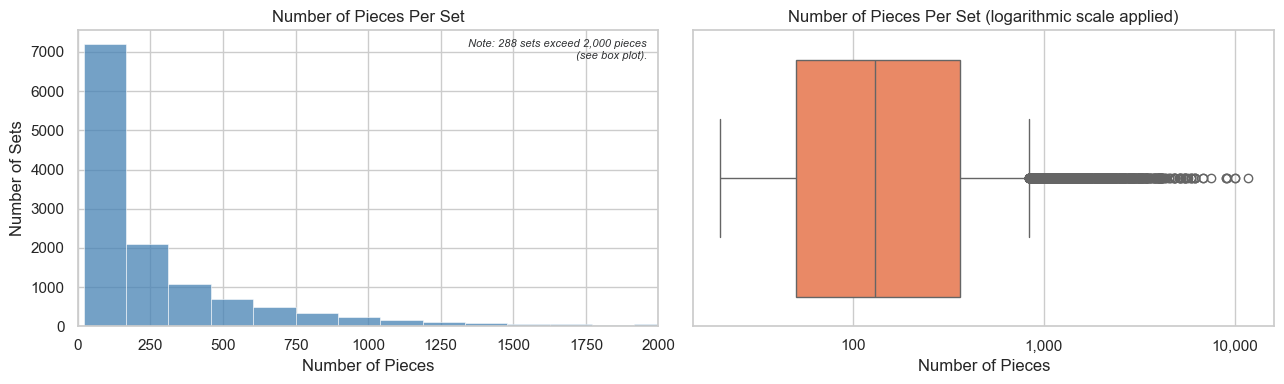

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# The histogram's x-axis is capped at 2000 pieces.
n_over = (sets['num_parts'] > 2000).sum()
sns.histplot(sets['num_parts'], bins=80, ax=axes[0], color='steelblue')
axes[0].set_xlim(0, 2000)
axes[0].set_title('Number of Pieces Per Set')
axes[0].set_xlabel('Number of Pieces')
axes[0].set_ylabel('Number of Sets')
axes[0].text(0.98, 0.97, f'Note: {n_over:,} sets exceed 2,000 pieces\n(see box plot).',
             transform=axes[0].transAxes, fontsize=8, va='top', ha='right',
             color='#303234', style='italic')

# The box plot has a logarithmic scale applied to it for readability.
sns.boxplot(x=sets['num_parts'], ax=axes[1], color='coral')
axes[1].set_xscale('log')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].set_title('Number of Pieces Per Set (logarithmic scale applied)')
axes[1].set_xlabel('Number of Pieces')

plt.tight_layout()
plt.savefig('figures/dist_num_parts.png', dpi=150)
plt.show()

#### 3.1 Conclusion

The vast majority of Lego sets have less than 500 pieces. This make sense because sets that have more pieces are likely to be more complex. Furthermore, sets with larger piece counts will cost more and will thus have a smaller audience.
- _Note_: Our dataset does not include any financial information, so the second part of the conclusion is an educated guess and may require further analysis,

### 3.2 Number of Sets Released Per Year (1954 – 2026)

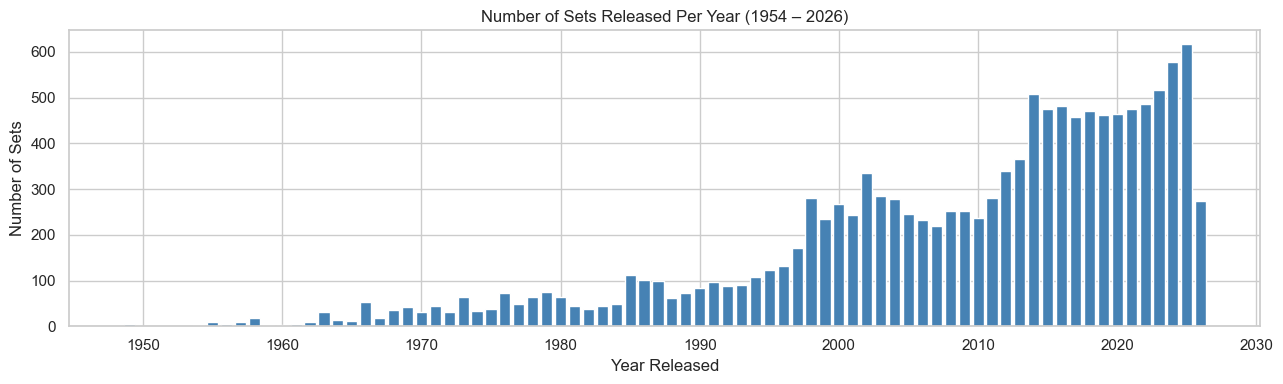

In [7]:
sets_per_year = sets.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(sets_per_year['year'], sets_per_year['count'], color='steelblue', width=0.8)
ax.set_title('Number of Sets Released Per Year (1954 – 2026)')
ax.set_xlabel('Year Released')
ax.set_ylabel('Number of Sets')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.savefig('figures/sets_per_year.png', dpi=150)
plt.show()

#### 3.2 Conclusion

The graph slowly rises from 1950s-1995 and had a huge boom in the early 2000s. Though, the number of sets dipped from late 2000s and early 2010s, (likely caused from the 2008 financial crisis) there was another sharp rise in the mid 2010s, which was followed by a steady yearly increase into the 2020s.


### 3.3 Piece Color Clarity Breakdown (Opaque vs Transparent)

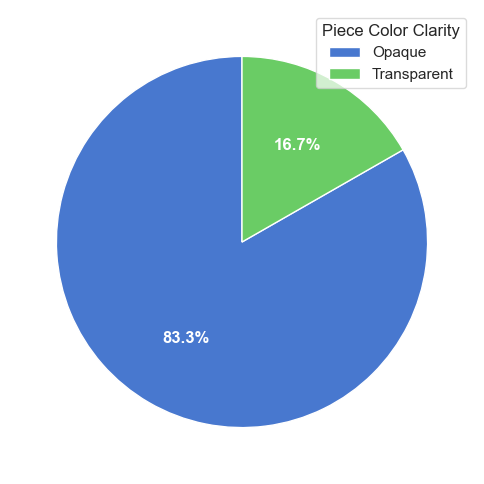

In [8]:
color_counts = colors['is_trans'].value_counts().rename({0: 'Opaque', 1: 'Transparent'})

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(color_counts, autopct='%1.1f%%',
       colors=['#4878cf', '#6acc65'], startangle=90,
       wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax.legend(wedges, color_counts.index, title='Piece Color Clarity',
          loc='upper right', framealpha=0.7)
plt.tight_layout()
plt.savefig('figures/color_transparency.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.2 Conclusion

A majority of sets (83.3%) use opaque pieces, but there is still a fair share of transparent peices among sets (16.7%).

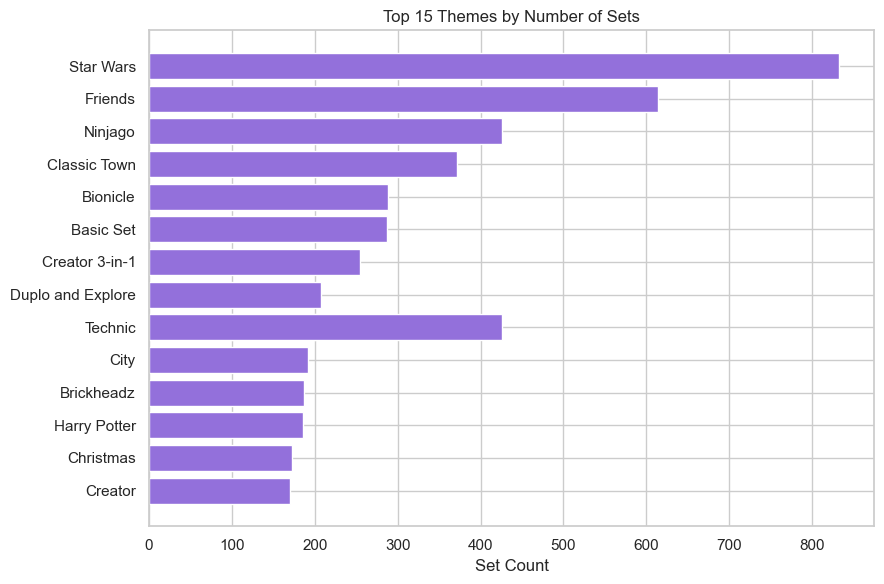

In [9]:
top_themes = (
    sets.groupby('theme_id').size()
        .reset_index(name='set_count')
        .merge(themes[['id', 'name']], left_on='theme_id', right_on='id')
        .nlargest(15, 'set_count')
        .sort_values('set_count')
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_themes['name'], top_themes['set_count'], color='mediumpurple')
ax.set_title('Top 15 Themes by Number of Sets')
ax.set_xlabel('Set Count')
plt.tight_layout()
plt.savefig('figures/top_themes.png', dpi=150)
plt.show()

#### 3.3 Conclusion

While Lego's in-house sets (e.g., Ninjago) dominate the top themes by number of pieces, (surpisingly) the most popular theme is a licenced theme: Star Wars. Notably, the top themes are for multi-media brands (e.g., movies, TV shows, books, etc.).

## 4 Relationship Analysis

### 4.1 Median Number of Pieces (`num_parts`) in Each Set Over Time

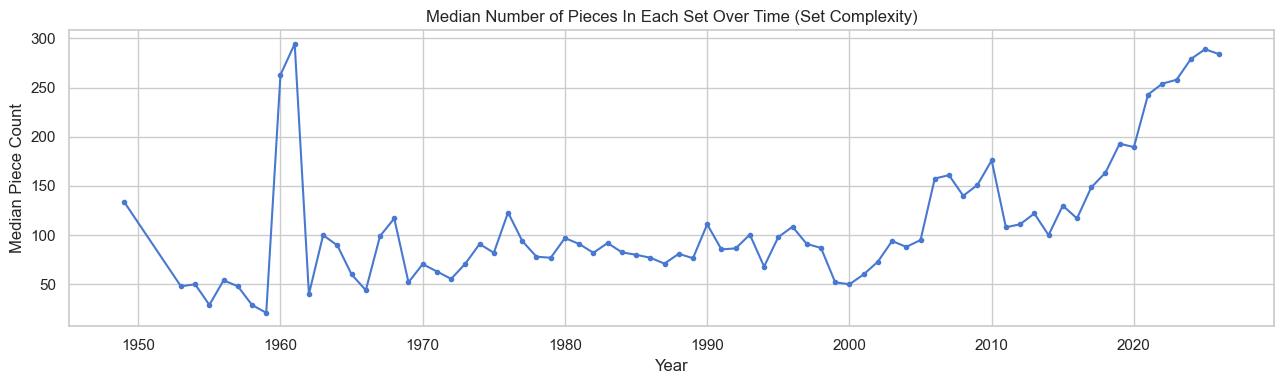

In [10]:
complexity = sets.groupby('year')['num_parts'].median().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(complexity['year'], complexity['num_parts'], marker='o', markersize=3,
        linewidth=1.5, color='b')
ax.set_title('Median Number of Pieces In Each Set Over Time (Set Complexity)')
ax.set_xlabel('Year')
ax.set_ylabel('Median Piece Count')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.savefig('figures/complexity_over_time.png', dpi=150)
plt.show()

#### 4.1 Conclusion

Overall, we can see a increase in the number of parts in a sets. The single outlier here being 1960 where only 2 sets released that year. Most notably though, we can see that there is a sharp increase in the median piece count of the sets beginning in the late 2010s. With more pieces, you will have higher complexity and price, supporting the claim the Lego has shifted to a more mature audience over time.
- _Note_: This dataset does not includes set age ranges (e.g., Ages 10+), so we cannot confirm that piece count has a direct correlation to set complexity. With that being said, it's probably a safe assumption to make.

### 4.2 Pearson Correlation: Year vs Number of Pieces (`num_parts`)

Correlation matrix (year, num_parts):


,year,num_parts
year,1.000000,0.212312
num_parts,0.212312,1.000000



Pearson r = 0.212
Pearson r (year vs num_parts) = 0.212
Pearson r (year vs log10(num_parts)) = 0.267


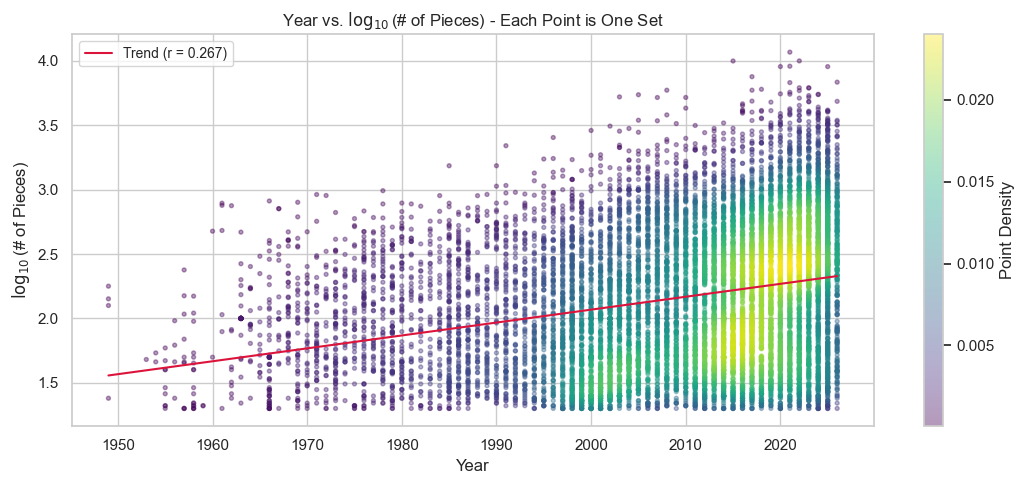

In [11]:
# View the correlation matrix between the year and the number of pieces
corr = sets[['year', 'num_parts']].corr()
print("Correlation matrix (year, num_parts):")
display(corr)

r = corr.loc['year', 'num_parts']
print(f"\nPearson r = {r:.3f}")


# Make a scatter plot to compare the year with the Pearson r value that has been log-transformed 
sets_nonzero = sets[sets['num_parts'] > 0].copy()
sets_nonzero['log_num_parts'] = np.log10(sets_nonzero['num_parts'])

log_r = sets_nonzero[['year', 'log_num_parts']].corr().loc['year', 'log_num_parts']
print(f"Pearson r (year vs num_parts) = {sets[['year','num_parts']].corr().loc['year','num_parts']:.3f}")
print(f"Pearson r (year vs log10(num_parts)) = {log_r:.3f}")

# Compute point density for coloring
x = sets_nonzero['year'].values
y = sets_nonzero['log_num_parts'].values
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)

# Trend line
slope, intercept, *_ = linregress(x, y)
x_line = np.array([x.min(), x.max()])
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(11, 5))
sc = ax.scatter(x, y, c=density, cmap='viridis', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='Point Density')
ax.plot(x_line, y_line, color='crimson', linewidth=1.5, label=f'Trend (r = {log_r:.3f})')
ax.legend(loc='upper left', fontsize=10)
ax.set_title(r'Year vs. $\log_{10}$(# of Pieces) - Each Point is One Set')
ax.set_xlabel('Year')
ax.set_ylabel(r'$\log_{10}$(# of Pieces)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.savefig('figures/scatter_year_vs_logparts.png', dpi=150)
plt.show()

#### 4.2 Conclusion
`num_parts` is heavily right-skewed, which supresses the raw Pearson r ($r = 0.216$). To improve linearity and give a more accurate correlation, we applied a $log_{10}$ transformation. Additionally, a linear regression line (in red) was added to make the upward trend more obvious.

It is clear that over time, more sets have been released with more pieces.

### 4.3 Distribution of Set Piece Count (`num_parts`) Across the Top 8 Themes

/var/folders/97/pfqd4qjx2hd931l7g_0_p4rr0000gn/T/ipykernel_71906/1781407563.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sets_top8, x='theme_name', y='num_parts', order=order,


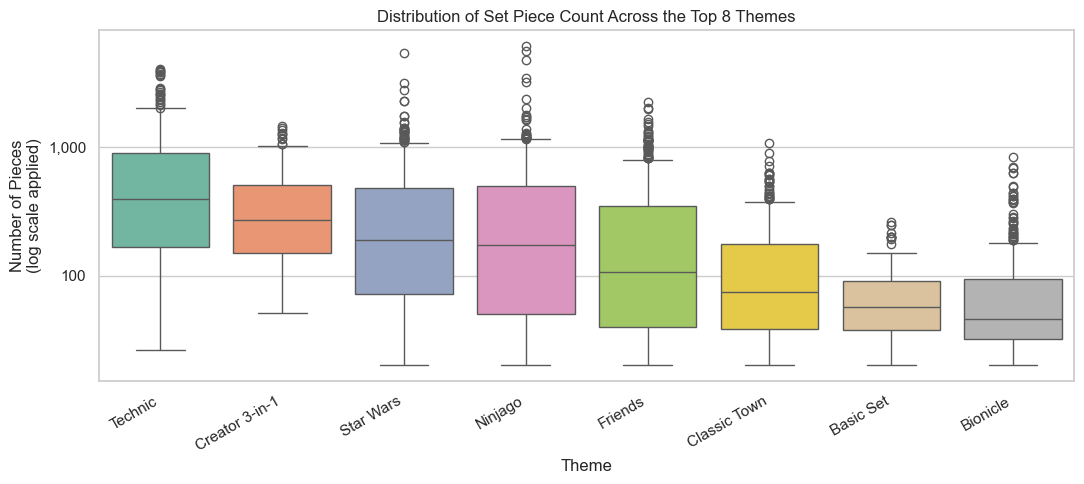

In [12]:
top8_ids = (
    sets.groupby('theme_id').size()
        .nlargest(8).index
)
sets_top8 = (
    sets[sets['theme_id'].isin(top8_ids)]
        .merge(
            themes[['id', 'name']].rename(columns={'name': 'theme_name'}),
            left_on='theme_id', right_on='id'
        )
)

order = (
    sets_top8.groupby('theme_name')['num_parts']
             .median().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=sets_top8, x='theme_name', y='num_parts', order=order,
            showfliers=True, palette='Set2', ax=ax)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{int(y):,}'))
ax.set_title('Distribution of Set Piece Count Across the Top 8 Themes')
ax.set_xlabel('Theme')
ax.set_ylabel('Number of Pieces\n(log scale applied)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figures/parts_by_theme.png', dpi=150)
plt.show()

#### 4.3 Conclusion

Across the top themes, spread in set size is large: themes like Technic skew toward large sets while Bionicle skews smaller.

### 4.4 Most Popular Brick Colors

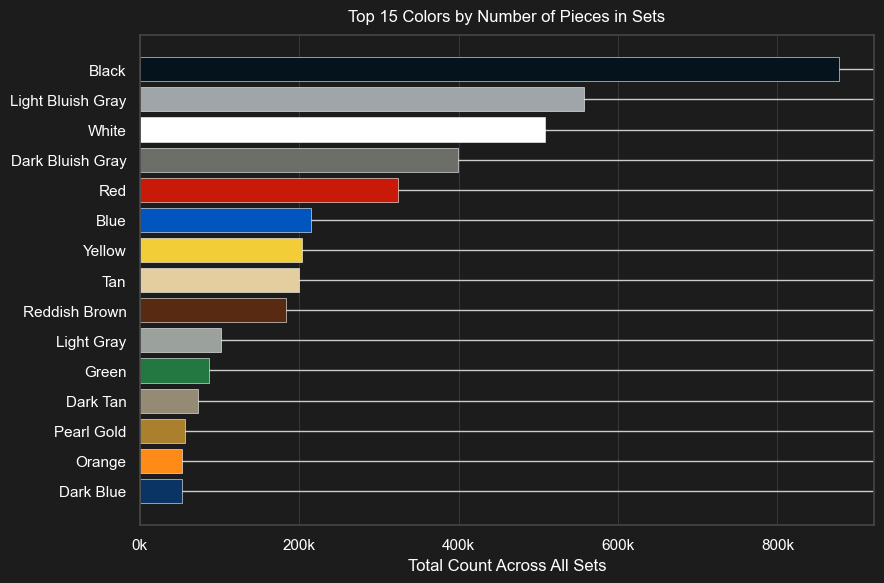

/Users/alex/Desktop/COSC-301-Project/db.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


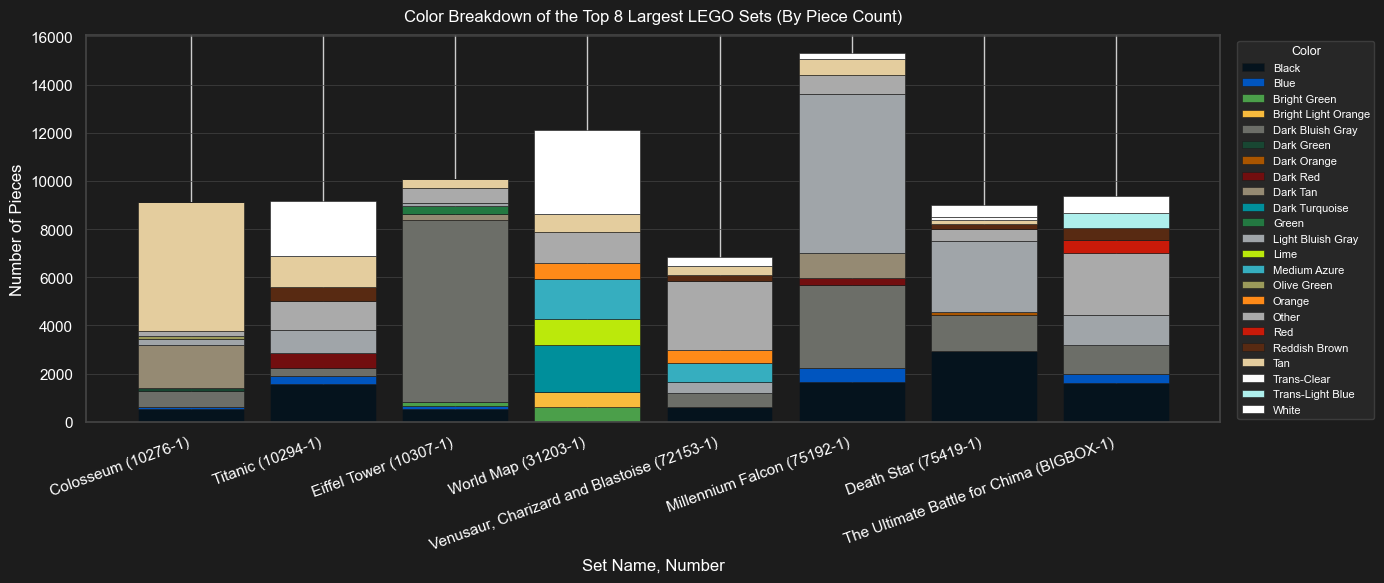

In [13]:
'''
Plot Top 15 Colors by Piece Count
'''
color_usage = (
    inv_parts.groupby('color_id')['quantity'].sum()
             .reset_index(name='total_qty')
             .merge(colors[['id', 'name', 'rgb', 'is_trans']], left_on='color_id', right_on='id')
             .nlargest(15, 'total_qty')
             .sort_values('total_qty')
)

bar_colors = ['#' + rgb if len(str(rgb)) == 6 else '#888888'
              for rgb in color_usage['rgb']]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#1c1c1c')
ax.set_facecolor('#1c1c1c')

bars = ax.barh(color_usage['name'], color_usage['total_qty'],
               color=bar_colors, edgecolor='white', linewidth=0.4)

ax.set_title('Top 15 Colors by Number of Pieces in Sets',
             color='white', pad=10)
ax.set_xlabel('Total Count Across All Sets', color='white')
ax.tick_params(colors='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')
ax.grid(axis='x', color='#444444', linewidth=0.5)

plt.tight_layout()
plt.savefig('figures/top_colors.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()


'''
Plot the Color Breakdown of the Top 8 Largest Sets (by Piece Count)
'''
inventories = query("SELECT * FROM inventories")

top8_sets = sets.nlargest(8, 'num_parts')[['set_num', 'name', 'num_parts']].copy()

# sets → inventories → inv_parts → colors
color_per_set = (
    top8_sets
    .merge(inventories[['id', 'set_num']], on='set_num')
    .rename(columns={'id': 'inventory_id'})
    .merge(inv_parts, on='inventory_id')
    .merge(
        colors[['id', 'name', 'rgb']].rename(columns={'id': 'color_id', 'name': 'color_name'}),
        on='color_id'
    )
    .groupby(['set_num', 'name', 'color_name', 'rgb'], as_index=False)['quantity'].sum()
)

# Keep only the top-N colors per set so bars stay readable; lump the rest as "Other"
TOP_N = 8
def top_n_colors(grp):
    grp = grp.sort_values('quantity', ascending=False)
    top = grp.head(TOP_N)
    other_qty = grp.iloc[TOP_N:]['quantity'].sum()
    if other_qty > 0:
        other_row = top.iloc[[0]].copy()
        other_row['color_name'] = 'Other'
        other_row['rgb']        = 'AAAAAA'
        other_row['quantity']   = other_qty
        top = pd.concat([top, other_row], ignore_index=True)
    return top

color_per_set = (
    color_per_set.groupby(['set_num', 'name'], group_keys=True)
                 .apply(top_n_colors, include_groups=False)
                 .reset_index(level=['set_num', 'name'])
                 .reset_index(drop=True)
)

# Pivot to wide form for stacked bar chart
pivot = (
    color_per_set
    .pivot_table(index=['set_num', 'name'], columns='color_name',
                 values='quantity', aggfunc='sum', fill_value=0)
)

# Short set labels: "Set Name (set_num)"
set_labels = [f"{n} ({s})" for s, n in pivot.index]

# Build a color map: color_name → hex
color_hex = (
    color_per_set[['color_name', 'rgb']]
    .drop_duplicates()
    .set_index('color_name')['rgb']
    .apply(lambda x: '#' + str(x) if not str(x).startswith('#') else x)
    .to_dict()
)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#1c1c1c')
ax.set_facecolor('#1c1c1c')

bottom = [0] * len(pivot)
for col in pivot.columns:
    vals = pivot[col].values
    hex_c = color_hex.get(col, '#AAAAAA')
    try:
        if len(hex_c.lstrip('#')) != 6:
            raise ValueError
        bars = ax.bar(set_labels, vals, bottom=bottom, label=col, color=hex_c,
                      edgecolor='#1c1c1c', linewidth=0.4)
    except (ValueError, TypeError):
        bars = ax.bar(set_labels, vals, bottom=bottom, label=col, color='#AAAAAA',
                      edgecolor='#1c1c1c', linewidth=0.4)
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_title('Color Breakdown of the Top 8 Largest LEGO Sets (By Piece Count)',
             color='white', pad=10)
ax.set_xlabel('Set Name, Number', color='white')
ax.set_ylabel('Number of Pieces', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')
ax.grid(axis='y', color='#444444', linewidth=0.5)
ax.legend(title='Color', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8,
          facecolor='#2b2b2b', edgecolor='#444444', labelcolor='white',
          title_fontsize=9)
ax.get_legend().get_title().set_color('white')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('figures/colors_top8_sets.png', dpi=150, facecolor=fig.get_facecolor())
plt.show()

#### 4.4 Conclusion
Black, light bluish grey, and white dominate total piece quantity. LEGO's palette is more neutral, which makes sense considering Star Wars is their most popular set theme (by number of sets).

## 5 Insight Summary

In [14]:
decade = sets.copy()
decade['decade'] = (decade['year'] // 10) * 10
summary = decade.groupby('decade')['num_parts'].agg(['median', 'mean', 'count'])
summary.columns = ['median_parts', 'mean_parts', 'set_count']
display(summary)

,median_parts,mean_parts,set_count
decade,,,
1940,134.0,117.500000,4
1950,40.0,50.466667,45
1960,80.0,130.072398,221
1970,79.5,134.258000,500
1980,81.0,152.976676,686
1990,83.0,180.129445,1406
2000,94.0,245.473563,2610
2010,139.0,319.897034,4079
2020,257.0,538.394251,3409


### 5 Conclusion

Set complexity has risen dramatically since the 1990s. The median number of pieces per set (`num_parts`) per set remained under ~65 pieces through the 1990s. Throughout the 2000s it has climbed steadily, reaching 207 pieces in the 2020s. The decade summary below shows this trajectory clearly. The raw Pearson r between `year` and `num_parts` ($r = 0.216$) understates the trend because `num_parts` is heavily right-skewed. After a $log_{10}$ transformation, the correlation is noticeably stronger, making `year` a more useful predictor than the raw $r$ alone suggests.

- _Note_: The 1940s row shows a median of 126 parts from only 5 sets. This is due to the small sample size of that time. The 5 sets happen to be large, but this is not necessarily not evidence that early LEGO sets were complex. A more accurate baseline is to read from the 1950s–1970s data.